# How to create a simple Sequential NN using pytorch

In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np

## 🧱 Step 1. Create a simple dataset

- Let’s start with a toy regression example:
- Predict y = 3x + 2 with some noise.

In [4]:
# Generate data
x = torch.linspace(-5, 5, 100).unsqueeze(1)   # shape [100, 1]
y = 3 * x + 2 + torch.randn(x.size()) * 0.5   # noisy linear relation

## 🧠 Step 2. Define a neural network

- Let’s build a 2-layer fully connected NN.
### 💡 Explanation:
- nn.Linear(in, out) creates a layer that does y = xW + b
- nn.ReLU() introduces non-linearity
- forward() defines how data flows through the network

In [5]:
class SimpleNN(nn.Module):
    def __init__(self):
        super(SimpleNN, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(1, 16),   # input → hidden
            nn.ReLU(),          # activation
            nn.Linear(16, 1)    # hidden → output
        )
        
    def forward(self, x):
        return self.net(x)

## ⚙️ Step 3. Instantiate the model, loss, and optimizer
- criterion defines how we measure error.
- optimizer updates model weights using gradients (here SGD).

In [6]:
model = SimpleNN()
criterion = nn.MSELoss()          # Mean Squared Error for regression
optimizer = optim.SGD(model.parameters(), lr=0.01)

## 🔁 Step 4. Training loop
- 💡 What happens each step:
1.	preds = model(x) → forward pass
2.	loss.backward() → PyTorch computes gradients for all parameters
3.	optimizer.step() → parameters updated based on gradients


In [7]:
for epoch in range(500):
    optimizer.zero_grad()          # reset gradients
    preds = model(x)               # forward pass
    loss = criterion(preds, y)     # compute loss
    loss.backward()                # compute gradients
    optimizer.step()               # update weights

    if epoch % 50 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item():.4f}")

Epoch 0, Loss: 76.4753
Epoch 50, Loss: 0.2704
Epoch 100, Loss: 0.2288
Epoch 150, Loss: 0.2196
Epoch 200, Loss: 0.2156
Epoch 250, Loss: 0.2132
Epoch 300, Loss: 0.2117
Epoch 350, Loss: 0.2105
Epoch 400, Loss: 0.2096
Epoch 450, Loss: 0.2089


## 📈 Step 5. Test and visualize

In [8]:
with torch.no_grad():  # no gradients needed
    test_x = torch.linspace(-5, 5, 100).unsqueeze(1)
    preds = model(test_x)

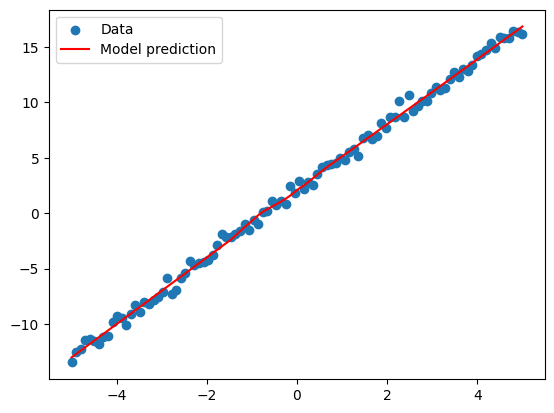

In [9]:
import matplotlib.pyplot as plt

plt.scatter(x, y, label='Data')
plt.plot(test_x, preds, color='red', label='Model prediction')
plt.legend()
plt.show()

# -------------------------------------------------- Linear Algebra of NN --------------------------------------------------------------------

In [10]:
import torch
x = torch.tensor([[1.0, 2.0]])       # input (1x2)
W = torch.tensor([[0.5], [0.2]], requires_grad=True)
b = torch.tensor([0.1], requires_grad=True)

y_pred = x @ W + b
loss = (y_pred - torch.tensor([[1.0]])) ** 2
loss.backward()

print("y_pred:", y_pred.item())
print("W.grad:", W.grad)
print("b.grad:", b.grad)

y_pred: 1.0
W.grad: tensor([[0.],
        [0.]])
b.grad: tensor([0.])


## Practice Questions
### Q1: We can do a hands-on exploration now to really internalize this:
- Create a tiny 2-layer network with tensors
- Print .grad_fn for every intermediate tensor
- Compute .backward()
- Inspect .grad for each parameter
- Try .detach() and no_grad to see how the graph is affected

In [11]:
x1 = torch.tensor(np.random.choice(range(1, 100), 3),dtype=torch.float32)
W1 = torch.tensor(np.random.choice(range(1, 10), 3),dtype=torch.float32, requires_grad=True)
b1 = torch.tensor(np.random.choice(range(1, 30), 3),dtype=torch.float32, requires_grad=True)
layer_1 = W1 @ x1 + b1
print("layer1:", layer_1)
print("layer1.grad_fn:", layer_1.grad_fn)
act_1 = torch.relu(layer_1)

W2 = torch.tensor(np.random.rand(3),dtype=torch.float32, requires_grad=True)
b2 = torch.tensor(np.random.rand(1),dtype=torch.float32, requires_grad=True)

output = W2 @ act_1 + b2
print("Output layer:", output)
print("Output Layer .grad_fn:", output.grad_fn)

loss = ((output - torch.tensor([1.0, 0.5, 2.0])) ** 2).sum()
print("loss:", loss)
print("loss.grad_fn:", loss.grad_fn)
loss.backward()

print("Gradients:")
print("dL/dW1:", W1.grad)
print("dL/db1:", b1.grad)
print("dL/dW2:", W2.grad)
print("dL/db2:", b2.grad)



layer1: tensor([203., 188., 193.], grad_fn=<AddBackward0>)
layer1.grad_fn: <AddBackward0 object at 0x1165f0970>
Output layer: tensor([324.5861], grad_fn=<AddBackward0>)
Output Layer .grad_fn: <AddBackward0 object at 0x1165f0970>
loss: tensor(313801.5312, grad_fn=<SumBackward0>)
loss.grad_fn: <SumBackward0 object at 0x1165f0970>
Gradients:
dL/dW1: tensor([35632.7422, 51829.4453,  6478.6807])
dL/db1: tensor([1020.9941, 1287.0176,  931.3286])
dL/dW2: tensor([393924.8750, 364817.1250, 374519.7188])
dL/db2: tensor([1940.5166])


### Q2: Manual 2-layer mini-MLP that mimics nn.Linear exactly, with weights shaped like PyTorch’s nn.Linear (out_features, in_features) and explicit .T for forward pass.

We’ll include:
- Forward pass
- ReLU activation
- Output layer
- Loss (MSE)
- Backpropagation
- Inspect .grad_fn and .grad

In [12]:
# ----------------------
# Step 1: Inputs
# ----------------------
# Batch of 2 samples, 3 features each
x = torch.tensor([[1.0, 2.0, 3.0],
                  [4.0, 5.0, 6.0]], dtype=torch.float32)

# ----------------------
# Step 2: First Layer (Linear)
# ----------------------
# Following PyTorch convention: W shape = (out_features, in_features)
W1 = torch.randn((4, 3), dtype=torch.float32, requires_grad=True)  # 4 hidden neurons
b1 = torch.randn((1, 4), dtype=torch.float32, requires_grad=True)  # broadcasted

# Forward pass: linear
z1 = x @ W1.T + b1  # shape: (batch_size, hidden_dim)
print("Layer 1 output z1:\n", z1)
print("z1.grad_fn:", z1.grad_fn)

# Activation
a1 = torch.relu(z1)
print("After ReLU a1:\n", a1)
print("a1.grad_fn:", a1.grad_fn)

# ----------------------
# Step 3: Second Layer (Output)
# ----------------------
# Output neurons = 2
W2 = torch.randn((2, 4), dtype=torch.float32, requires_grad=True)  # out_features x in_features
b2 = torch.randn((1, 2), dtype=torch.float32, requires_grad=True)

# Forward pass
z2 = a1 @ W2.T + b2  # shape: (batch_size, out_features)
print("Output layer z2:\n", z2)
print("z2.grad_fn:", z2.grad_fn)

# ----------------------
# Step 4: Loss
# ----------------------
y_true = torch.tensor([[0.5, 1.0],
                       [1.5, 2.0]], dtype=torch.float32)

loss = ((z2 - y_true)**2).mean()
print("Loss:", loss)
print("loss.grad_fn:", loss.grad_fn)

# ----------------------
# Step 5: Backprop
# ----------------------
loss.backward()

# Inspect gradients
print("Gradients:")
print("W1.grad:\n", W1.grad)
print("b1.grad:\n", b1.grad)
print("W2.grad:\n", W2.grad)
print("b2.grad:\n", b2.grad)

Layer 1 output z1:
 tensor([[-1.2855, -0.3176, -0.7593,  6.6340],
        [-2.8235,  2.5181, -2.7813, 17.8316]], grad_fn=<AddBackward0>)
z1.grad_fn: <AddBackward0 object at 0x11671df00>
After ReLU a1:
 tensor([[ 0.0000,  0.0000,  0.0000,  6.6340],
        [ 0.0000,  2.5181,  0.0000, 17.8316]], grad_fn=<ReluBackward0>)
a1.grad_fn: <ReluBackward0 object at 0x11430f5b0>
Output layer z2:
 tensor([[ 4.3102,  8.4283],
        [ 5.0679, 18.4827]], grad_fn=<AddBackward0>)
z2.grad_fn: <AddBackward0 object at 0x11430f5b0>
Loss: tensor(88.5266, grad_fn=<MeanBackward0>)
loss.grad_fn: <MeanBackward0 object at 0x11430f5b0>
Gradients:
W1.grad:
 tensor([[  0.0000,   0.0000,   0.0000],
        [-41.1023, -51.3779, -61.6535],
        [  0.0000,   0.0000,   0.0000],
        [ 44.4134,  59.3325,  74.2515]])
b1.grad:
 tensor([[  0.0000, -10.2756,   0.0000,  14.9190]])
W2.grad:
 tensor([[  0.0000,   4.4923,   0.0000,  44.4494],
        [  0.0000,  20.7529,   0.0000, 171.5963]])
b2.grad:
 tensor([[ 3.6891, 1

In [13]:
W1

tensor([[ 0.6857, -0.5993, -0.5991],
        [ 0.9674,  1.0380, -1.0601],
        [ 0.3280, -0.8842, -0.1178],
        [ 1.1152,  1.8844,  0.7330]], requires_grad=True)

In [14]:
x

tensor([[1., 2., 3.],
        [4., 5., 6.]])

## NN with Pytorch

#### Simple one layer NN with one neuron (see output dims is 1)

In [15]:
class MyNN(nn.Module):

    def __init__(self, input_dims, output_dims):
        super().__init__()
        self.my_lin_mod = nn.Linear(input_dims, output_dims)
    
    def forward(self, input_x):
        return self.my_lin_mod(input_x)

In [16]:
model = MyNN(2,1)
for name, param in model.named_parameters():
    print(f"Name: {name}\tParam:{param}")

Name: my_lin_mod.weight	Param:Parameter containing:
tensor([[0.2828, 0.6149]], requires_grad=True)
Name: my_lin_mod.bias	Param:Parameter containing:
tensor([0.0410], requires_grad=True)


In [17]:
x = torch.randn(4,2)
output = model(x)
print(f"Outout: {output}")

Outout: tensor([[ 0.7097],
        [-0.0729],
        [ 0.4169],
        [ 0.3070]], grad_fn=<AddmmBackward0>)


#### Simple NN with activation layer

In [18]:
class NNwithActivation(nn.Module):

    def __init__(self, input_dims,hidden_dims, output_dims):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dims, hidden_dims),
            nn.ReLU(),
            nn.Linear(hidden_dims, output_dims)
        )
    def forward(self, input_x):
        return self.model(input_x)
    
model = NNwithActivation(2, 3, 1)
input = torch.randn(4, 2)
output = model(input)
print(output)

tensor([[0.4488],
        [0.5177],
        [0.5234],
        [0.5810]], grad_fn=<AddmmBackward0>)


In [19]:
print(list(model.named_parameters()))

[('model.0.weight', Parameter containing:
tensor([[ 0.6100,  0.2980],
        [ 0.4120, -0.1882],
        [ 0.5832, -0.4256]], requires_grad=True)), ('model.0.bias', Parameter containing:
tensor([ 0.4870,  0.6970, -0.1181], requires_grad=True)), ('model.2.weight', Parameter containing:
tensor([[ 0.0545,  0.2369, -0.3046]], requires_grad=True)), ('model.2.bias', Parameter containing:
tensor([0.3638], requires_grad=True))]


### Activation Functions
#### 🔸 ReLU & LeakyReLU

##### ReLU (Rectified Linear Unit) 
$$ f(x) = max(0, x) ----> [0, ∞)$$
 - Most common for hidden layers; fast, avoids vanishing gradients
 - nn.ReLU()

##### Leaky ReLU
$$ 
 f(x) = max(0.01x, x) ---> (-∞, ∞)
$$
- Like ReLU but small negative slope prevents “dying” neurons
- nn.LeakyReLU(0.01)







In [ ]:
relu = nn.ReLU()
leaky = nn.LeakyReLU(0.01)
x = torch.tensor([[-2.0, -0.5, 0.5, 3.0]])
print("ReLU:", relu(x))
print("LeakyReLU:", leaky(x)) 

ReLU: tensor([[0.0000, 0.0000, 0.5000, 3.0000]])
LeakyReLU: tensor([[-0.0200, -0.0050,  0.5000,  3.0000]])


#### 🔸 Sigmoid & Tanh

##### Sigmoid
$$ f(x) = \frac{1}{1 + e^{-x}} ----> (0, 1) $$
-  Binary classification output; squashes values to probability
- nn.Sigmoid()
-  The sum of probabilities might be greater thean 1 coz the probability pertains to independent classes
##### Tanh
$$ f(x) = \tanh(x) = \frac{e^x - e^{-x}}{e^x + e^{-x}} ----> (-1, 1) $$
- Centered at 0; good for intermediate layers when outputs can be neg/pos
- nn.Tanh()


In [ ]:
sig = nn.Sigmoid() 
tanh = nn.Tanh()
print("Sigmoid:", sig(x))
print("Tanh:", tanh(x))

Sigmoid: tensor([[0.1192, 0.3775, 0.6225, 0.9526]])
Tanh: tensor([[-0.9640, -0.4621,  0.4621,  0.9951]])


#### 🔸 Softmax
$$f(x_i) = \frac{e^{x_i}}{\sum_j e^{x_j}}  ----> (0, 1), sum = 1 $$
- Multi-class classification output layer (probability distribution)
- The probabilties are of classes that are not independent but mutually exclusive.
- nn.Softmax(dim=1)


In [22]:
softmax = nn.Softmax(dim=1)
print("Softmax:", softmax(x))
print("Sum across classes:", softmax(x).sum(dim=1))  # should be 1

Softmax: tensor([[0.0060, 0.0270, 0.0734, 0.8936]])
Sum across classes: tensor([1.])


| Case | Type of Classes | Activation | Why |
|------|----------------|-----------|-----|
| Mutually Exclusive Classes | Only one can be true at a time (e.g., cat or dog or horse) | Softmax | Ensures probabilities sum to 1; encourages “competition” between outputs |
| Independent Classes | Multiple can be true at once (e.g., image has a cat and a dog) | Sigmoid | Treats each output as an independent yes/no probability |

### Loss Functions

#### 1️⃣ Why Loss Functions
- Loss functions quantify how wrong the model predictions are compared to the true labels.
- Backpropagation computes gradients of the loss w.r.t. every parameter to guide weight updates.
#### 2️⃣ Common Losses
| Task | Output Activation | PyTorch Loss | Notes |
|------|-----------------|--------------|-------|
| Regression | Linear (no activation) | nn.MSELoss() | Mean Squared Error; continuous outputs |
| Binary Classification | Sigmoid | nn.BCEWithLogitsLoss() | Combines sigmoid + BCE in a numerically stable way |
| Multi-class Classification | Softmax | nn.CrossEntropyLoss() | Expects raw logits; softmax applied internally |
| Multi-label Classification | Sigmoid | nn.BCEWithLogitsLoss() | Independent yes/no outputs per label |

3️⃣ Key Points
1.	MSELoss:
$$\text{loss} = \frac{1}{N}\sum_i (\hat{y}_i - y_i)^2$$
2.	Binary Cross-Entropy:
$$\text{loss} = -\frac{1}{N} \sum_i \left[ y_i \log(\hat{y}_i) + (1 - y_i)\log(1 - \hat{y}_i) \right]$$
- Sigmoid applied inside BCEWithLogitsLoss → numerical stability
3.	Cross-Entropy (multi-class):
- Takes raw logits
- Softmax + log likelihood applied internally
- Output: scalar loss across batch


In [23]:
# Regression
y_true = torch.tensor([[2.0], [0.5]])
y_pred = torch.tensor([[1.8], [0.4]])
mse = nn.MSELoss()
print("MSE:", mse(y_pred, y_true).item())

# Binary Classification (sigmoid output)
y_true_bin = torch.tensor([[1.0], [0.0]])
logits = torch.tensor([[0.8], [-1.2]])  # raw outputs
bce = nn.BCEWithLogitsLoss()
print("BCEWithLogits:", bce(logits, y_true_bin).item())

# Multi-class Classification (softmax inside CrossEntropyLoss)
y_true_class = torch.tensor([2, 0])  # class indices
logits_multi = torch.tensor([[1.0, 2.0, 3.0],
                             [2.0, 1.0, 0.1]])  # raw logits
ce = nn.CrossEntropyLoss()
print("CrossEntropy:", ce(logits_multi, y_true_class).item())

MSE: 0.025000007823109627
BCEWithLogits: 0.31719154119491577
CrossEntropy: 0.4123179316520691


#### Optimizers

1️⃣ Why Optimizers
- Backprop gives us gradients of loss w.r.t. each parameter.
- Optimizers define how to update the parameters using those gradients.
- Key idea: move weights in the direction that minimizes the loss.

2️⃣ Common Optimizers in PyTorch

| Optimizer | Formula / Update Rule | Notes |
|-----------|----------------------|-------|
| SGD | \( \theta \leftarrow \theta - \eta \nabla_\theta L \) | Vanilla gradient descent; learning rate \(\eta\) controls step size |
| SGD + Momentum | \( v = \gamma v + \eta \nabla_\theta L, \quad \theta \leftarrow \theta - v \) | Momentum smooths updates; \(\gamma \approx 0.9\) |
| Adam | Adaptive LR using running estimates of first & second moments | Widely used; generally fast convergence |
| RMSprop | Adaptive learning rate dividing by sqrt of avg squared gradients | Good for non-stationary problems |

4️⃣ Key Points to Remember

1.	Zero gradients each step: optimizer.zero_grad() prevents accumulation from previous batches.
2.	Step updates weights: optimizer.step() applies the gradient descent update.
3.	Learning rate matters: too high → divergence, too low → slow convergence.
4.	Momentum/Adam help smooth updates and adapt learning rates per parameter.

In [26]:
model = nn.Sequential(nn.Linear(2,3), nn.ReLU(), nn.Linear(3,1))
optimizer = torch.optim.SGD(model.parameters(), lr=0.01, momentum=0.9)
loss_fn = nn.MSELoss()

# Dummy data
x = torch.randn(5,2)
y = torch.randn(5,1)

# Forward pass
y_pred = model(x)
loss = loss_fn(y_pred, y)

# Backward pass
optimizer.zero_grad()   # reset gradients
loss.backward()         # compute gradients
optimizer.step()        # update weights

print(list(model.named_parameters()))

[('0.weight', Parameter containing:
tensor([[ 0.6898,  0.3240],
        [ 0.2403, -0.2691],
        [ 0.4686, -0.4359]], requires_grad=True)), ('0.bias', Parameter containing:
tensor([-0.1607,  0.0101,  0.5816], requires_grad=True)), ('2.weight', Parameter containing:
tensor([[-0.3549, -0.4802,  0.5148]], requires_grad=True)), ('2.bias', Parameter containing:
tensor([0.0095], requires_grad=True))]


#### Batch Training Loop
1️⃣ Why Batch Training
- Neural networks are typically trained on mini-batches, not single samples, for efficiency and stable gradients.
- Each iteration:
	1.	Forward pass: compute predictions
	2.	Compute loss
	3.	Backward pass: compute gradients
	4.	Optimizer step: update weights

2️⃣ Key Notes for Interviews
1.	Zero gradients each batch: optimizer.zero_grad()
2.	Forward → loss → backward → step is the standard sequence
3.	Mini-batches:
- Larger batch → smoother gradients, slower updates
- Smaller batch → noisier gradients, potentially better generalization
4.	Learning rate is critical: too high → divergence; too low → slow convergence

5.	Can combine with:
- Momentum or Adam
- Learning rate schedules
- Regularization like dropout



In [40]:
class TwoLayerNN(nn.Module):

    def __init__(self, input_dims, hidden_dims, output_dims):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dims, hidden_dims),
            nn.ReLU(),
            nn.Linear(hidden_dims, output_dims)
        )
    def forward(self, input_x):
        return self.model(input_x)
    
epochs = 100
model = TwoLayerNN(2, 3, 1)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)


X = torch.randn(1000, 2)
y = torch.rand(1000, 1)
len_x = len(X)

batch_size = 50
for epoch in range(epochs):
    model.train()
    for i in range(0, len_x, batch_size):
        optimizer.zero_grad()
        X_batch = X[i: i + batch_size]
        y_batch = y[i: i + batch_size]
        y_pred = model(X_batch)
        loss = criterion(y_pred, y_batch)
        loss.backward()
        optimizer.step()
    model.eval()
    with torch.no_grad():
        y_val_pred = model(X)
    if epoch % 10 == 0:
        print(f"pred on train set:\t pre:{y_val_pred[0]}\t Actual: {y[0]}")
        print(f"Epoch {epoch+1}, Loss: {loss.item():.4f}") 


pred on train set:	 pre:tensor([0.6443])	 Actual: tensor([0.0795])
Epoch 1, Loss: 0.1983
pred on train set:	 pre:tensor([0.7089])	 Actual: tensor([0.0795])
Epoch 11, Loss: 0.1143
pred on train set:	 pre:tensor([0.6265])	 Actual: tensor([0.0795])
Epoch 21, Loss: 0.1105
pred on train set:	 pre:tensor([0.5893])	 Actual: tensor([0.0795])
Epoch 31, Loss: 0.1100
pred on train set:	 pre:tensor([0.5684])	 Actual: tensor([0.0795])
Epoch 41, Loss: 0.1092
pred on train set:	 pre:tensor([0.5454])	 Actual: tensor([0.0795])
Epoch 51, Loss: 0.1094
pred on train set:	 pre:tensor([0.5265])	 Actual: tensor([0.0795])
Epoch 61, Loss: 0.1102
pred on train set:	 pre:tensor([0.5171])	 Actual: tensor([0.0795])
Epoch 71, Loss: 0.1106
pred on train set:	 pre:tensor([0.5140])	 Actual: tensor([0.0795])
Epoch 81, Loss: 0.1107
pred on train set:	 pre:tensor([0.5131])	 Actual: tensor([0.0795])
Epoch 91, Loss: 0.1107


#### 🧩 1️⃣ Why initialization matters
##### Analogy
Imagine training is like hiking toward the minimum of the loss surface.
- Initialization = where you start on the hill.
- Bad initialization = you start on a steep cliff (exploding gradients) or flat plateau (vanishing gradients).
- Good initialization = gentle slope toward the valley (stable gradient flow).

When you start training a neural network:
- Each layer transforms its input → passes it to the next.
- During backprop, gradients flow backward through those same weights.

- If weights are too small, activations and gradients shrink exponentially as they pass through layers → vanishing gradients.
- If weights are too large, activations and gradients explode exponentially → exploding gradients.

- So, initialization controls how stable the forward and backward signals are.
#### 🧮 2️⃣ Modern initialization rules of thumb
| Initialization       | Formula (fan_in, fan_out)                | Best for            | Activation          |
|----------------------|------------------------------------------|---------------------|---------------------|
| **Xavier (Glorot)**  | Var(W) = 2 / (fan_in + fan_out)          | Balanced networks   | Tanh, Sigmoid       |
| **He (Kaiming)**     | Var(W) = 2 / fan_in                      | Deep networks       | ReLU, LeakyReLU     |
| **Uniform variants** | Use ±√(limit) around 0                   | Same logic applies  | Depends on activation |

PyTorch’s nn.Linear uses a variant of Kaiming uniform initialization by default, which works well for ReLU.

In [41]:


layer = nn.Linear(256, 128)

# Xavier initialization
nn.init.xavier_uniform_(layer.weight)

# He initialization
nn.init.kaiming_normal_(layer.weight, nonlinearity='relu')

Parameter containing:
tensor([[ 0.1684, -0.1164,  0.0442,  ...,  0.0558, -0.0142, -0.0090],
        [ 0.0638, -0.1575, -0.1688,  ...,  0.1329,  0.1678, -0.0423],
        [-0.0031,  0.0061, -0.0225,  ...,  0.0008, -0.1325, -0.0857],
        ...,
        [ 0.1155,  0.0269, -0.0245,  ...,  0.1122, -0.0874,  0.0387],
        [ 0.1378,  0.0849, -0.0391,  ...,  0.0756,  0.0993,  0.1599],
        [-0.0988, -0.1086,  0.0413,  ..., -0.0398, -0.0699,  0.0091]],
       requires_grad=True)

#### 🧩 When you have different activation functions in the same deep network

1️⃣ Each activation affects gradient flow differently
- Each activation has its own scale of outputs and gradient behavior:

| Activation   | Typical Output Range | Gradient Range | Notes                                      |
|---------------|----------------------|----------------|--------------------------------------------|
| **ReLU**      | [0, ∞)              | 0 or 1         | Sparse activations; may kill neurons (dying ReLU) |
| **LeakyReLU** | (−∞, ∞)             | α or 1         | Keeps gradient alive for negatives         |
| **Sigmoid**   | (0, 1)              | small (0–0.25) | Saturates easily → vanishing gradients     |
| **Tanh**      | (−1, 1)             | small (0–1)    | Zero-centered but can still vanish         |

2️⃣ So what does PyTorch (and you) do?
- You initialize per layer, depending on the activation used right after it.

3️⃣ Bonus — how PyTorch automates this
PyTorch’s built-in layers already apply activation-appropriate defaults internally:
- nn.Linear uses Kaiming uniform assuming ReLU (most common).
- If you have non-ReLU activations, you can override via reset_parameters() or nn.init.

So you only need to customize when you deviate from ReLU-type activations.o y


In [42]:
layers = nn.ModuleList([
    nn.Linear(128, 64),
    nn.ReLU(),
    nn.Linear(64, 32),
    nn.Tanh(),
    nn.Linear(32, 1)
])

# Initialize layer by layer
nn.init.kaiming_uniform_(layers[0].weight, nonlinearity='relu')
nn.init.xavier_uniform_(layers[2].weight, gain=nn.init.calculate_gain('tanh'))
nn.init.xavier_uniform_(layers[4].weight)

Parameter containing:
tensor([[-0.1430,  0.1530, -0.4232,  0.2862, -0.1057,  0.2211, -0.2348,  0.3794,
         -0.3570,  0.0515,  0.0611,  0.1836,  0.0306, -0.2914,  0.2475, -0.3496,
         -0.2677, -0.0005,  0.4169,  0.2294, -0.3923,  0.3601,  0.1830, -0.0422,
         -0.3490,  0.0232, -0.4039,  0.1365,  0.2592, -0.0238, -0.1372, -0.2133]],
       requires_grad=True)

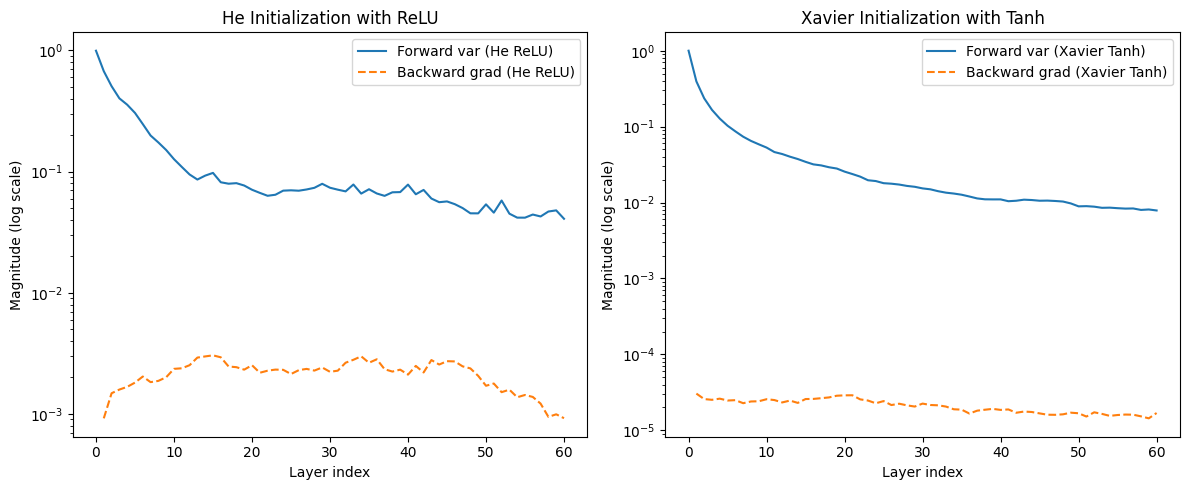

In [48]:


torch.manual_seed(42)
np.random.seed(42)

def make_linear_layer(in_f, out_f):
    return nn.Linear(in_f, out_f, bias=False)

def init_he(layer):
    nn.init.kaiming_normal_(layer.weight, nonlinearity='relu')

def init_xavier(layer):
    nn.init.xavier_normal_(layer.weight)

def forward_backward_flow(n_layers=50, fan_in=256, batch_size=256, activation='relu', init_fn=init_he):
    layers = [make_linear_layer(fan_in, fan_in) for _ in range(n_layers)]
    for l in layers:
        init_fn(l)

    act = torch.relu if activation == 'relu' else torch.tanh

    # Input tensor (leaf) with requires_grad
    x = torch.randn(batch_size, fan_in, requires_grad=True)
    
    # Forward pass: collect per-layer output variance
    cur = x
    forward_vars = [cur.var(dim=0).mean().item()]  # input variance as layer 0
    for l in layers:
        cur = l(cur)
        cur = act(cur)
        forward_vars.append(cur.var(dim=0).mean().item())
    
    # Backward pass: simple scalar loss for backprop
    loss = cur.mean()
    loss.backward()

    # Collect mean absolute gradient per layer
    backward_grads = [l.weight.grad.abs().mean().item() for l in layers]

    return forward_vars, backward_grads

def plot_combined_flow(n_layers=60, fan_in=256, batch_size=256):
    layers_idx = list(range(n_layers+1))  # include input

    # Example: He init for ReLU
    fwd_he_relu, bwd_he_relu = forward_backward_flow(n_layers, fan_in, batch_size, activation='relu', init_fn=init_he)
    fwd_xavier_tanh, bwd_xavier_tanh = forward_backward_flow(n_layers, fan_in, batch_size, activation='tanh', init_fn=init_xavier)

    plt.figure(figsize=(12,5))

    plt.subplot(1,2,1)
    plt.plot(layers_idx, fwd_he_relu, label='Forward var (He ReLU)', linestyle='-')
    plt.plot(layers_idx[1:], bwd_he_relu, label='Backward grad (He ReLU)', linestyle='--')
    plt.yscale('log')
    plt.title('He Initialization with ReLU')
    plt.xlabel('Layer index')
    plt.ylabel('Magnitude (log scale)')
    plt.legend()

    plt.subplot(1,2,2)
    plt.plot(layers_idx, fwd_xavier_tanh, label='Forward var (Xavier Tanh)', linestyle='-')
    plt.plot(layers_idx[1:], bwd_xavier_tanh, label='Backward grad (Xavier Tanh)', linestyle='--')
    plt.yscale('log')
    plt.title('Xavier Initialization with Tanh')
    plt.xlabel('Layer index')
    plt.ylabel('Magnitude (log scale)')
    plt.legend()

    plt.tight_layout()
    plt.show()

if __name__ == '__main__':
    plot_combined_flow()

### 🧠 Dropout — Intuition

- Dropout randomly “turns off” neurons during training to prevent the network from relying too heavily on any single activation.
- At inference time, dropout is turned off, but activations are scaled appropriately.

Formally:
$$ h’ = \frac{mask \odot h}{(1 - p)} $$
where
- mask ∈ {0,1} is drawn from Bernoulli(p),
- p = dropout probability (fraction of units dropped).

💯 Exactly right — you’ve got it.

Let’s break that down precisely 👇

⸻

#### ✅ Meaning of p=0.5 in Dropout

When you define

- nn.Dropout(p=0.5)

- it means:

- “During training, for each forward pass, randomly set 50% of the neuron activations to 0.”

- So if your input to dropout is:

- [0.3, 0.8, 0.1, 0.5]

- then (with p=0.5) you might get something like:

[- 0.6, 0.0, 0.2, 0.0]

- because:
- two of the activations (≈50%) were randomly zeroed out,
- the remaining ones were scaled by 1 / (1 - p) = 2.0 to maintain the same expected sum of activations.

⸻

##### ⚙️ Why scale by 1 / (1 - p)?

Without scaling, the expected activation magnitude would drop by 50% during training,
so PyTorch rescales the surviving activations upward to keep their overall magnitude consistent between training and inference.

That’s why at inference (model.eval()), dropout simply passes the data through — no random masking, no scaling needed.

⸻

🧠 So in short

- Mode	Behavior	Example (p=0.5)
- Training (model.train())	Randomly zero 50% of activations, scale others by 2.0	[0.3, 0.8, 0.1, 0.5] → [0.6, 0.0, 0.2, 0.0]
- Eval (model.eval())	No dropout, all activations pass through	[0.3, 0.8, 0.1, 0.5] → [0.3, 0.8, 0.1, 0.5]

Each neuron’s “survival” during a forward pass is an independent Bernoulli trial:
- Probability of being kept: 1-p
- Probability of being dropped: p


In [49]:
layer = nn.Sequential(
    nn.Linear(128, 64),
    nn.ReLU(),
    nn.Dropout(p=0.5),
    nn.Linear(64, 10)
)

In [70]:
torch.manual_seed(42)   
# Create a dropout layer with 50% probability
drop = nn.Dropout(p=0.5)

# Dummy input tensor
x = torch.tensor([[0.3, 0.8, 0.1, 0.5]])

# ----- Training mode -----
drop.train()  # enables dropout
train_out = drop(x)

# ----- Evaluation mode -----
drop.eval()   # disables dropout
eval_out = drop(x)

print("Input:      ", x)
print("Train mode: ", train_out)
print("Eval mode:  ", eval_out)

Input:       tensor([[0.3000, 0.8000, 0.1000, 0.5000]])
Train mode:  tensor([[0.6000, 1.6000, 0.2000, 1.0000]])
Eval mode:   tensor([[0.3000, 0.8000, 0.1000, 0.5000]])


🧩 Batch Normalization — Intuition

BatchNorm normalizes the outputs of a layer so that they have a stable mean and variance.

Why it matters
- Deep networks can suffer from internal covariate shift: activations change distribution as weights update.
- This slows training because each layer has to adapt to changing inputs.
- BatchNorm stabilizes the distribution, allowing:
- Faster training
- Higher learning rates
- Reduced sensitivity to weight initialization

⸻

🧮 Mathematics

For a mini-batch x = [x_1, x_2, …, x_m] (activations of a layer):
1. Compute batch mean and variance:

$$
\mu_B = \frac{1}{m} \sum_{i=1}^m x_i, \quad
\sigma_B^2 = \frac{1}{m} \sum_{i=1}^m (x_i - \mu_B)^2
$$

2. Normalize activations:

$$
\hat{x}_i = \frac{x_i - \mu_B}{\sqrt{\sigma_B^2 + \epsilon}}
$$

3. Scale and shift with learnable parameters:

$$
y_i = \gamma \hat{x}_i + \beta
$$

- $\gamma$ = scale (learnable)  
- $\beta$ = shift (learnable)  
- $\epsilon$ = small constant for numerical stability

This allows the network to learn the optimal mean and variance, rather than forcing strict zero-mean/unit-variance.


In [74]:


# ----------------------------
# Sample Data
# ----------------------------
batch_size = 5
input_dim = 3  # number of features / neurons
X = torch.randn(batch_size, input_dim)
y = torch.randn(batch_size, input_dim)  # target same shape for demo

# ----------------------------
# Simple Model: Linear + BatchNorm + ReLU
# ----------------------------
class SimpleBNNet(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.linear = nn.Linear(input_dim, input_dim)
        self.bn = nn.BatchNorm1d(input_dim)  # per-feature normalization
        self.relu = nn.ReLU()

    def forward(self, x):
        out = self.linear(x)
        out = self.bn(out)
        out = self.relu(out)
        return out

model = SimpleBNNet(input_dim)
criterion = nn.MSELoss()
optimizer = optim.SGD(model.parameters(), lr=0.01)

# ----------------------------
# Inspect initial γ and β
# ----------------------------
print("Initial γ (weight):", model.bn.weight)
print("Initial β (bias):", model.bn.bias)

# ----------------------------
# Forward pass (training mode)
# ----------------------------
model.train()  # training mode uses batch statistics
out = model(X)
print("\nForward output (train):\n", out)

# ----------------------------
# Backward pass
# ----------------------------
loss = criterion(out, y)
loss.backward()

print("\nGradients:")
print("Linear weights grad:\n", model.linear.weight.grad)
print("BatchNorm γ grad:\n", model.bn.weight.grad)
print("BatchNorm β grad:\n", model.bn.bias.grad)

# ----------------------------
# Update parameters
# ----------------------------
optimizer.step()

# ----------------------------
# Forward pass (eval mode)
# ----------------------------
model.eval()  # uses running mean/variance
with torch.no_grad():
    out_eval = model(X)
print("\nForward output (eval):\n", out_eval)

Initial γ (weight): Parameter containing:
tensor([1., 1., 1.], requires_grad=True)
Initial β (bias): Parameter containing:
tensor([0., 0., 0.], requires_grad=True)

Forward output (train):
 tensor([[1.2890, 0.0000, 0.0000],
        [0.0000, 1.4463, 1.8357],
        [0.0000, 0.0000, 0.0000],
        [0.9565, 0.0000, 0.0000],
        [0.0000, 0.7765, 0.0000]], grad_fn=<ReluBackward0>)

Gradients:
Linear weights grad:
 tensor([[-0.0958,  0.1256,  0.0576],
        [-0.0446,  0.0505, -0.1383],
        [-0.0780,  0.0169, -0.0598]])
BatchNorm γ grad:
 tensor([0.5447, 0.4612, 0.7614])
BatchNorm β grad:
 tensor([0.4776, 0.3927, 0.4148])

Forward output (eval):
 tensor([[1.2059, 0.0000, 0.0000],
        [0.3933, 0.2355, 0.6104],
        [0.4949, 0.0000, 0.0000],
        [1.0539, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.0000]])


### Learning Rate Schedules
1️⃣ Why Learning Rate Schedules?
- The learning rate controls the step size during gradient descent.
- A constant LR can be inefficient:
- Too high → overshoot minima, unstable training.
- Too low → slow convergence, might get stuck in suboptimal minima.
- LR schedules adapt the learning rate over time to improve convergence and generalization.

| Schedule Type | How It Works | Notes / Use Case |
|---------------|--------------|------------------|
| **Step Decay** | Reduce LR by a factor every fixed number of epochs (e.g., 0.1 every 10 epochs) | Simple, widely used in classical CV/ML tasks |
| **Exponential Decay** | LR ← LR × γ^epoch | Smooth decay, γ ∈ (0,1) |
| **Cosine Annealing** | LR follows a cosine curve from initial LR to a minimum | Helps avoid overshooting and encourages escaping shallow minima |
| **Cyclical LR** | LR cycles between lower and upper bounds | Can accelerate training and avoid local minima |
| **OneCycle Policy** | LR increases then decreases within one epoch cycle | Popular in modern PyTorch training (fast convergence) |
| **Adaptive Optimizers (Adam, RMSProp)** | Implicitly adjust per-parameter learning rate | Often combined with explicit LR schedules |



In [86]:
# Simple dataset
X = torch.randn(100, 2)
y = torch.randn(100, 1)

# Define model
class SimpleNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(2, 4),
            nn.ReLU(),
            nn.Linear(4, 1)
        )
    def forward(self, x):
        return self.model(x)

model = SimpleNN()
criterion = nn.MSELoss()
optimizer = optim.SGD(model.parameters(), lr=0.1)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)

# Training loop
def train(scheduler, optimizer):
    model.train()
    for epoch in range(30):
        optimizer.zero_grad()
        y_pred = model(X)
        loss = criterion(y_pred, y)
        loss.backward()
        optimizer.step()
        scheduler.step()

        # print learning rate every 5 epochs
        if epoch % 5 == 0:
            lr = scheduler.get_last_lr()[0]
            print(f"Epoch {epoch:2d} | Loss: {loss.item():.4f} | LR: {lr:.5f}")

#### Step LR

In [87]:


optimizer = optim.SGD(model.parameters(), lr=0.1)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.1)

train(scheduler, optimizer)

Epoch  0 | Loss: 1.4161 | LR: 0.10000
Epoch  5 | Loss: 1.1228 | LR: 0.10000
Epoch 10 | Loss: 1.1160 | LR: 0.01000
Epoch 15 | Loss: 1.1156 | LR: 0.01000
Epoch 20 | Loss: 1.1153 | LR: 0.00100
Epoch 25 | Loss: 1.1152 | LR: 0.00100


#### Cosine Annealing

In [85]:
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=50)
train(scheduler, optimizer)

Epoch  0 | Loss: 1.0232 | LR: 0.00010
Epoch  5 | Loss: 1.0232 | LR: 0.00010
Epoch 10 | Loss: 1.0232 | LR: 0.00009
Epoch 15 | Loss: 1.0232 | LR: 0.00008
Epoch 20 | Loss: 1.0232 | LR: 0.00006
Epoch 25 | Loss: 1.0232 | LR: 0.00005


#### OneCycle

In [93]:
from torch.utils.data import Dataset

class MyDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]
    
class SimpleNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(2, 4),
            nn.ReLU(),
            nn.Linear(4, 1)
        )
    def forward(self, x):
        return self.model(x)

In [91]:
def train_batch(model, X_batch, y_batch, optimizer, criterion):
    optimizer.zero_grad()
    y_pred = model(X_batch)
    loss = criterion(y_pred, y_batch)
    loss.backward()
    optimizer.step()
    return loss.item()

In [100]:
from torch.utils.data import DataLoader, TensorDataset
model = SimpleNN()
criterion = nn.MSELoss()
optimizer = optim.SGD(model.parameters(), lr=0.01)

# --- DataLoader ---
dataset = MyDataset(X, y)
train_loader = DataLoader(dataset, batch_size=32, shuffle=True)

# --- OneCycleLR ---

train_loader = MyDataset(X, y)
scheduler = optim.lr_scheduler.OneCycleLR(
    optimizer, max_lr=0.001, steps_per_epoch=len(train_loader), epochs=10
)
epochs = 10
for epoch in range(epochs):
    model.train()
    batch_losses = []
    for X_batch, y_batch in train_loader:
        loss = train_batch(model, X_batch, y_batch, optimizer, criterion)
        batch_losses.append(loss)
        scheduler.step()  # OneCycleLR must step every batch
    for param_group in optimizer.param_groups:
        print(f"Lr: {param_group['lr']}")
    print(f"Epoch {epoch+1}, Loss: {sum(batch_losses)/len(batch_losses):.4f}")

Lr: 0.0002814573614486898
Epoch 1, Loss: 1.7927
Lr: 0.0007629058733040791
Epoch 2, Loss: 1.1978
Lr: 0.0009999949645161446
Epoch 3, Loss: 1.1692
Lr: 0.000949506469528491
Epoch 4, Loss: 1.1607
Lr: 0.0008099881015401792
Epoch 5, Loss: 1.1548
Lr: 0.0006090731844117885
Epoch 6, Loss: 1.1489
Lr: 0.0003865553815403508
Epoch 7, Loss: 1.1415
Lr: 0.00018650707278631586
Epoch 8, Loss: 1.1325
Lr: 4.855027912992059e-05
Epoch 9, Loss: 1.1237
Lr: 9.035483855369958e-09
Epoch 10, Loss: 1.1185


# Gradient Clipping

**Purpose:**  
Prevent exploding gradients in deep networks by capping the magnitude of gradients during backpropagation.

---

**How it Works:**

1. **Compute total gradient norm** (usually L2 norm) across all model parameters:  
\[
\text{total\_norm} = \sqrt{\sum_i ||g_i||_2^2}
\]  
where \(g_i\) is the gradient tensor of parameter \(i\).

2. **Compare with max norm:**  
If `total_norm > max_norm`, compute a scaling factor:  
\[
\text{scale} = \frac{\text{max\_norm}}{\text{total\_norm}}
\]

3. **Scale all gradients proportionally:**  
\[
g_i \leftarrow g_i \times \text{scale}
\]  
This keeps the gradient direction the same while limiting its magnitude.

---

**PyTorch Implementation:**

```python
import torch.nn.utils as utils

# Clip gradients to max_norm
utils.clip_grad_norm_(model.parameters(), max_norm)

In [101]:
from torch.nn.utils import clip_grad_norm_

# Simple model
model = nn.Sequential(
    nn.Linear(10, 50),
    nn.ReLU(),
    nn.Linear(50, 1)
)

optimizer = optim.Adam(model.parameters(), lr=0.01)
criterion = nn.MSELoss()

# Dummy batch
X = torch.randn(32, 10)
y = torch.randn(32, 1)

# Forward pass
optimizer.zero_grad()
y_pred = model(X)
loss = criterion(y_pred, y)

# Backward pass
loss.backward()

# Gradient clipping
clip_grad_norm_(model.parameters(), max_norm=1.0)  # Clip gradients

# Update weights
optimizer.step()

### Hyperparameter Tuning & Cross-Validation in PyTorch

####  1️⃣ Hyperparameter Tuning

**Definition:**  
Process of finding the best set of model parameters (not learned via gradient descent) such as learning rate, hidden dimensions, dropout probability, optimizer type, batch size, etc.

**Common Techniques:**
- **Grid Search:** Exhaustive search over a predefined parameter grid.  
  - Pros: Simple, guarantees coverage of grid.  
  - Cons: Very slow for large search spaces.
- **Random Search:** Random sampling of hyperparameter combinations.  
  - Pros: Faster, can explore large search spaces efficiently.  
  - Cons: May miss optimal regions.
- **Bayesian / Sequential Optimization (Optuna, HyperOpt):** Uses previous trials to guide next hyperparameter selection.  
  - Pros: Efficient, often finds better solutions faster.  
  - Cons: Slightly more complex to implement.

**PyTorch Integration:**  
- Wrap the training process inside an **objective function** that receives hyperparameters as input.
- Compute **validation loss** or metric and return it to the tuner.
- Libraries: [Optuna](https://optuna.org/), [Ray Tune](https://docs.ray.io/en/latest/tune/index.html), HyperOpt.

---

#### 2️⃣ Cross-Validation (CV)

**Definition:**  
Technique to assess model generalization performance by splitting the dataset into multiple training and validation folds.

**k-Fold CV:**
- Split dataset into k equal parts (folds).
- Train the model k times; each time one fold is held out as validation, the rest used for training.
- Final performance metric = average across folds.

**Benefits:**
- Reduces bias from a single train/validation split.
- Gives more reliable estimate of model performance.
- Useful when dataset is small.

**Implementation with PyTorch:**
- Use `Subset` or `SubsetRandomSampler` to create training/validation sets per fold.
- Wrap training in a loop across folds.
- Compute mean validation loss as the objective for hyperparameter tuning.

---

#### 3️⃣ Combined Hyperparameter Tuning + CV Workflow

1. Define a **PyTorch model class** with variable hyperparameters (hidden size, dropout, etc.).
2. Wrap **training + evaluation** inside an **objective function**.
3. For each trial:
   - Perform **k-fold CV**.
   - Train the model on training folds.
   - Validate on the held-out fold.
   - Compute average validation loss across folds.
4. Hyperparameter tuner (Optuna) selects the next trial based on previous results.
5. After tuning, train **final model on full dataset** using the best hyperparameters.

**Key Notes:**
- Always reset optimizer and model per fold to avoid information leakage.
- Can combine with **early stopping** to avoid wasting computation on poor trials.
- Objective function should return **validation performance** (e.g., MSE, accuracy, etc.) rather than training loss.
- Batch size, learning rate, dropout, hidden dimensions, and optimizer type are commonly tuned parameters.

---

#### 4️⃣ PyTorch Specific Tips

- Wrap evaluation in `with torch.no_grad():` to save memory.
- Use `model.train()` and `model.eval()` appropriately to ensure Dropout and BatchNorm behave correctly.
- For reproducibility, set random seeds for PyTorch, NumPy, and any dataset shuffling.

---

**References:**
- [Optuna Documentation](https://optuna.org/)
- [PyTorch K-Fold CV Example](https://pytorch.org/tutorials/)

In [103]:

from torch.utils.data import DataLoader, TensorDataset, Subset
from sklearn.model_selection import KFold
import optuna

# -------------------------
# 1️⃣ Dataset
# -------------------------
X = torch.randn(1000, 10)  # Features
y = torch.randn(1000, 1)   # Targets
dataset = TensorDataset(X, y)

# -------------------------
# 2️⃣ Model definition
# -------------------------
class SimpleMLP(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim, dropout_p):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(p=dropout_p),
            nn.Linear(hidden_dim, output_dim)
        )
    def forward(self, x):
        return self.model(x)

# -------------------------
# 3️⃣ Objective function for Optuna
# -------------------------
def objective(trial):
    # Hyperparameters
    hidden_dim = trial.suggest_int("hidden_dim", 16, 128)
    lr = trial.suggest_loguniform("lr", 1e-4, 1e-1)
    dropout_p = trial.suggest_float("dropout_p", 0.0, 0.5)
    batch_size = trial.suggest_categorical("batch_size", [32, 64, 128])
    optimizer_name = trial.suggest_categorical("optimizer", ["Adam", "SGD"])

    k_folds = 5
    kfold = KFold(n_splits=k_folds, shuffle=True, random_state=42)
    fold_losses = []

    for train_idx, val_idx in kfold.split(dataset):
        train_subset = Subset(dataset, train_idx)
        val_subset = Subset(dataset, val_idx)

        train_loader = DataLoader(train_subset, batch_size=batch_size, shuffle=True)
        val_loader = DataLoader(val_subset, batch_size=batch_size, shuffle=False)

        model = SimpleMLP(input_dim=X.shape[1], hidden_dim=hidden_dim, output_dim=1, dropout_p=dropout_p)
        criterion = nn.MSELoss()
        if optimizer_name == "Adam":
            optimizer = optim.Adam(model.parameters(), lr=lr)
        else:
            optimizer = optim.SGD(model.parameters(), lr=lr, momentum=0.9)

        # Training loop per fold
        epochs = 50
        best_val_loss = float("inf")
        patience = 5
        trigger_times = 0

        for epoch in range(epochs):
            # Train
            model.train()
            for X_batch, y_batch in train_loader:
                optimizer.zero_grad()
                y_pred = model(X_batch)
                loss = criterion(y_pred, y_batch)
                loss.backward()
                optimizer.step()

            # Validation
            model.eval()
            val_loss_total = 0.0
            with torch.no_grad():
                for X_val, y_val in val_loader:
                    y_val_pred = model(X_val)
                    val_loss_total += criterion(y_val_pred, y_val).item() * X_val.size(0)
            val_loss_total /= len(val_loader.dataset)

            # Early stopping
            if val_loss_total < best_val_loss:
                best_val_loss = val_loss_total
                trigger_times = 0
            else:
                trigger_times += 1
                if trigger_times >= patience:
                    break

        fold_losses.append(best_val_loss)

    # Return mean validation loss across folds
    return sum(fold_losses) / len(fold_losses)

# -------------------------
# 4️⃣ Run Optuna study
# -------------------------
study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=30)

print("Best trial:")
trial = study.best_trial
print(f"  Value (CV Loss): {trial.value}")
print("  Params: ")
for key, value in trial.params.items():
    print(f"    {key}: {value}")

# -------------------------
# 5️⃣ Train final model on full dataset
# -------------------------
best_params = trial.params
final_model = SimpleMLP(input_dim=X.shape[1],
                        hidden_dim=best_params["hidden_dim"],
                        output_dim=1,
                        dropout_p=best_params["dropout_p"])
final_optimizer = optim.Adam(final_model.parameters(), lr=best_params["lr"])
final_criterion = nn.MSELoss()
final_loader = DataLoader(dataset, batch_size=best_params["batch_size"], shuffle=True)

for epoch in range(50):
    final_model.train()
    for X_batch, y_batch in final_loader:
        final_optimizer.zero_grad()
        y_pred = final_model(X_batch)
        loss = final_criterion(y_pred, y_batch)
        loss.backward()
        final_optimizer.step()

print("Final model training completed with best hyperparameters from CV.")

/Users/shubhambhardwaj/Shubham/datascience/study/LLM/embeddings/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[I 2025-11-12 11:56:47,595] A new study created in memory with name: no-name-38072735-c964-4c1a-8ee1-a9df6e2e48c3
/var/folders/pw/ct2l9dz532s3m_xxwd5ngrth0000gn/T/ipykernel_2498/1874349555.py:33: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  lr = trial.suggest_loguniform("lr", 1e-4, 1e-1)
[I 2025-11-12 11:56:48,225] Trial 0 finished with value: 0.9691668097972871 and parameters: {'hidden_dim': 23, 'lr': 0.0006188088606840909, 'dropout_p': 0.4482898707406047, 'batch_size': 32, 'optimizer': 'SGD'}. Best is trial 0 with value: 0.969

Best trial:
  Value (CV Loss): 0.9595991969108582
  Params: 
    hidden_dim: 16
    lr: 0.018163657485540496
    dropout_p: 0.49305254502250995
    batch_size: 64
    optimizer: SGD
Final model training completed with best hyperparameters from CV.
